# Meta-Learner Classifier Check

This notebook evaluates a leakage-aware meta-learner classifier on the two-season meta dataset.

Changes versus the first draft:
- explicit meta-feature selection so baseline columns are not silently reused as features
- classifiers are evaluated as **probabilistic** models, not only as hard `0/1` predictions
- manual **time-aware sigmoid calibration** inside each outer walk-forward fold
- probability quality metrics: **Brier score** and **log loss**
- selective betting summaries using probability thresholds instead of only a `0.5` cutoff

Protocol:
- same anchored walk-forward split strategy used in the regressor notebook
- smaller train/test fold sizes because only two seasons are available
- binary target: `over` vs `under` from `LINE_ERROR`
- no Optuna yet
- compare unweighted and recency-weighted classifiers


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from pandas.api.types import is_bool_dtype, is_numeric_dtype
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    log_loss,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from meta_learner_baselines import (
    BASE_AVG_ALL_6_ERR_COL,
    BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_FULL_DATASET_ERR_COL,
    add_default_meta_learner_baselines,
)
from nba_ou.modeling.modeling import (
    assert_valid_time_splits,
    build_recency_sample_weights,
    make_test_anchored_walk_forward_splits,
    split_latest_dates_holdout,
)


In [3]:
CSV_PATH = Path('/home/adrian_alvarez/Projects/NBA_over_under_predictor/data/train_data/meta_learner_last_2_seasons_20260405.csv')
DATE_COL = 'GAME_DATE'
TARGET_ERROR_COL = 'LINE_ERROR'
TARGET_CLASS_COL = 'TARGET_IS_OVER'
FINAL_HOLDOUT_SIZE = 0.08

TRAIN_GAMES = 1000
TEST_GAMES = 20
STEP_GAMES_BETWEEN_TESTS = 40
MIN_TRAIN_GAMES = int(TRAIN_GAMES * 0.75)
MAX_FOLDS = 15

SAMPLE_WEIGHT_LAMBDA = 0.0075
CALIBRATION_FRACTION = 0.20
MIN_CALIBRATION_GAMES = 150
MIN_MODEL_TRAIN_GAMES = 500
CONFIDENCE_THRESHOLDS = (0.55, 0.58, 0.60, 0.62, 0.65)

INCLUDE_BASELINE_FEATURES = False
BASELINE_ERROR_COLS = [
    BASE_AVG_ALL_6_ERR_COL,
    BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_FULL_DATASET_ERR_COL,
]

RAW_MODEL_PREDICTION_COLS = [
    'PRED_TOTAL_POINTS_FULL_DATASET',
    'PRED_TOTAL_POINTS_LAST_5_SEASONS',
    'PRED_TOTAL_POINTS_LAST_3_SEASONS',
    'PRED_LINE_ERROR_FULL_DATASET',
    'PRED_LINE_ERROR_LAST_5_SEASONS',
    'PRED_LINE_ERROR_LAST_3_SEASONS',
]

NON_FEATURE_COLS = [
    'GAME_ID',
    'GAME_DATE',
    'SEASON_YEAR',
    'TEAM_ID_TEAM_HOME',
    'TEAM_ID_TEAM_AWAY',
    'TOTAL_POINTS',
    'LINE_ERROR',
    TARGET_CLASS_COL,
]


In [4]:
def coerce_feature_column(series: pd.Series) -> pd.Series:
    if is_numeric_dtype(series) or is_bool_dtype(series):
        return series

    non_null = series.dropna()
    if non_null.empty:
        return pd.to_numeric(series, errors='coerce')

    normalized = non_null.astype(str).str.strip().str.lower()
    bool_mapping = {
        'true': 1.0,
        'false': 0.0,
        'yes': 1.0,
        'no': 0.0,
        'y': 1.0,
        'n': 0.0,
        't': 1.0,
        'f': 0.0,
        '0': 0.0,
        '1': 1.0,
    }
    if normalized.isin(bool_mapping).all():
        mapped = series.astype('string').str.strip().str.lower().map(bool_mapping)
        return pd.to_numeric(mapped, errors='coerce')

    numeric = pd.to_numeric(series, errors='coerce')
    if int(numeric.notna().sum()) == int(series.notna().sum()):
        return numeric

    return series



def coerce_feature_frame(df_features: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    output = df_features.copy()
    for column in output.columns:
        output[column] = coerce_feature_column(output[column])

    dropped_columns = [
        column
        for column in output.columns
        if not (is_numeric_dtype(output[column]) or is_bool_dtype(output[column]))
    ]
    if dropped_columns:
        output = output.drop(columns=dropped_columns)

    return output, dropped_columns



def error_to_binary(values: pd.Series | np.ndarray) -> np.ndarray:
    numeric = pd.to_numeric(pd.Series(values), errors='coerce').to_numpy(dtype=float)
    return (numeric > 0).astype(int)



def build_meta_feature_columns(
    df: pd.DataFrame,
    *,
    non_feature_cols: list[str],
    baseline_error_cols: list[str],
    include_baseline_features: bool,
) -> list[str]:
    excluded = set(non_feature_cols)
    if not include_baseline_features:
        excluded.update(baseline_error_cols)
    return [column for column in df.columns if column not in excluded]



def build_fit_kwargs(estimator, sample_weight: np.ndarray | None) -> dict[str, np.ndarray]:
    if sample_weight is None:
        return {}
    if isinstance(estimator, Pipeline):
        final_step_name = estimator.steps[-1][0]
        return {f'{final_step_name}__sample_weight': sample_weight}
    return {'sample_weight': sample_weight}



def predict_positive_class_probability(estimator, X: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, 'predict_proba'):
        proba = estimator.predict_proba(X)[:, 1]
    elif hasattr(estimator, 'decision_function'):
        decision = np.asarray(estimator.decision_function(X), dtype=float)
        proba = 1.0 / (1.0 + np.exp(-decision))
    else:
        raise TypeError('Estimator must expose predict_proba or decision_function.')
    return np.clip(np.asarray(proba, dtype=float), 1e-6, 1 - 1e-6)



def split_train_calibration_tail(
    train_idx: np.ndarray,
    *,
    calibration_fraction: float,
    min_calibration_games: int,
    min_model_train_games: int,
) -> tuple[np.ndarray, np.ndarray]:
    n_train = int(len(train_idx))
    calibration_games = max(min_calibration_games, int(round(n_train * calibration_fraction)))
    calibration_games = min(calibration_games, n_train - min_model_train_games)

    if calibration_games <= 0:
        raise ValueError('Not enough training rows to create a calibration tail.')

    model_train_idx = train_idx[:-calibration_games]
    calibration_idx = train_idx[-calibration_games:]
    if len(model_train_idx) < min_model_train_games:
        raise ValueError('Model-training split is smaller than min_model_train_games.')

    return model_train_idx, calibration_idx



def _logit(values: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(values, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(clipped / (1.0 - clipped))



def fit_sigmoid_calibrator(raw_proba: np.ndarray, y_true: pd.Series | np.ndarray) -> dict[str, object]:
    y = np.asarray(y_true, dtype=int)
    if len(np.unique(y)) < 2:
        return {'kind': 'constant', 'probability': float(np.mean(y))}

    x = _logit(raw_proba).reshape(-1, 1)
    calibrator = LogisticRegression(solver='lbfgs', max_iter=2000)
    calibrator.fit(x, y)
    return {'kind': 'sigmoid', 'model': calibrator}



def apply_sigmoid_calibrator(calibrator: dict[str, object], raw_proba: np.ndarray) -> np.ndarray:
    if calibrator['kind'] == 'constant':
        probability = float(calibrator['probability'])
        return np.full(len(raw_proba), probability, dtype=float)

    x = _logit(raw_proba).reshape(-1, 1)
    return np.clip(
        np.asarray(calibrator['model'].predict_proba(x)[:, 1], dtype=float),
        1e-6,
        1 - 1e-6,
    )



def make_prediction_frame(
    *,
    y_true: pd.Series | np.ndarray,
    y_pred: pd.Series | np.ndarray,
    model_name: str,
    scope: str,
    fold: int | None,
    proba_over: np.ndarray | None = None,
) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            'model': model_name,
            'scope': scope,
            'fold': fold,
            'y_true': np.asarray(y_true, dtype=int),
            'y_pred': np.asarray(y_pred, dtype=int),
        }
    )
    frame['proba_over'] = (
        np.nan if proba_over is None else np.asarray(proba_over, dtype=float)
    )
    return frame



def summarize_prediction_frame(predictions: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, float | int | str]] = []
    for model_name, group in predictions.groupby('model', sort=False):
        y_true = group['y_true'].to_numpy(dtype=int)
        y_pred = group['y_pred'].to_numpy(dtype=int)
        row: dict[str, float | int | str] = {
            'model': model_name,
            'n_games': int(len(group)),
            'accuracy_pct': 100.0 * accuracy_score(y_true, y_pred),
            'balanced_accuracy_pct': 100.0 * balanced_accuracy_score(y_true, y_pred),
            'pred_over_rate_pct': 100.0 * float(np.mean(y_pred)),
            'actual_over_rate_pct': 100.0 * float(np.mean(y_true)),
        }

        valid_proba = group['proba_over'].notna().all()
        if valid_proba:
            proba = group['proba_over'].to_numpy(dtype=float)
            row['brier_score'] = float(brier_score_loss(y_true, proba))
            row['log_loss'] = float(log_loss(y_true, proba, labels=[0, 1]))
            row['mean_confidence_pct'] = 100.0 * float(np.mean(np.maximum(proba, 1 - proba)))
        else:
            row['brier_score'] = np.nan
            row['log_loss'] = np.nan
            row['mean_confidence_pct'] = np.nan

        rows.append(row)

    return pd.DataFrame(rows).sort_values('accuracy_pct', ascending=False).reset_index(drop=True)



def summarize_betting_thresholds(
    predictions: pd.DataFrame,
    *,
    thresholds: tuple[float, ...],
) -> pd.DataFrame:
    rows: list[dict[str, float | int | str]] = []

    valid_predictions = predictions.dropna(subset=['proba_over']).copy()
    for model_name, group in valid_predictions.groupby('model', sort=False):
        y_true = group['y_true'].to_numpy(dtype=int)
        proba = group['proba_over'].to_numpy(dtype=float)
        total_games = len(group)

        for threshold in thresholds:
            over_mask = proba >= threshold
            under_mask = proba <= (1.0 - threshold)
            take_mask = over_mask | under_mask
            n_bets = int(take_mask.sum())

            if n_bets == 0:
                bet_accuracy = np.nan
                over_bets = 0
                under_bets = 0
            else:
                chosen_side = over_mask[take_mask].astype(int)
                bet_accuracy = 100.0 * accuracy_score(y_true[take_mask], chosen_side)
                over_bets = int(over_mask.sum())
                under_bets = int(under_mask.sum())

            rows.append(
                {
                    'model': model_name,
                    'threshold': threshold,
                    'n_bets': n_bets,
                    'pct_of_games': 100.0 * n_bets / total_games,
                    'bet_accuracy_pct': bet_accuracy,
                    'over_bets': over_bets,
                    'under_bets': under_bets,
                }
            )

    return pd.DataFrame(rows)



def build_reliability_table(
    predictions: pd.DataFrame,
    *,
    n_bins: int = 10,
) -> pd.DataFrame:
    valid_predictions = predictions.dropna(subset=['proba_over']).copy()
    valid_predictions['prob_bin'] = pd.cut(
        valid_predictions['proba_over'],
        bins=np.linspace(0.0, 1.0, n_bins + 1),
        include_lowest=True,
    )

    grouped = (
        valid_predictions.groupby(['model', 'prob_bin'], observed=False)
        .agg(
            n_games=('y_true', 'size'),
            mean_predicted_prob=('proba_over', 'mean'),
            empirical_over_rate=('y_true', 'mean'),
        )
        .reset_index()
    )
    grouped['empirical_over_rate'] = 100.0 * grouped['empirical_over_rate']
    grouped['mean_predicted_prob'] = 100.0 * grouped['mean_predicted_prob']
    return grouped



def evaluate_error_space_baselines_over_splits(
    df: pd.DataFrame,
    *,
    target_col: str,
    baseline_error_cols: list[str],
    splits: list[tuple[np.ndarray, np.ndarray]],
    scope_name: str,
) -> pd.DataFrame:
    frames = []
    for fold_num, (_, test_idx) in enumerate(splits, start=1):
        y_true = df.iloc[test_idx][target_col]
        for column in baseline_error_cols:
            y_pred = error_to_binary(df.iloc[test_idx][column])
            frames.append(
                make_prediction_frame(
                    y_true=y_true,
                    y_pred=y_pred,
                    model_name=column,
                    scope=scope_name,
                    fold=fold_num,
                )
            )
    return pd.concat(frames, ignore_index=True)



def run_classifier_cv(
    *,
    model_specs: list[tuple[str, object, bool]],
    X: pd.DataFrame,
    y: pd.Series,
    dates: pd.Series,
    splits: list[tuple[np.ndarray, np.ndarray]],
    sample_weight_lambda: float,
    calibration_fraction: float,
    min_calibration_games: int,
    min_model_train_games: int,
) -> pd.DataFrame:
    frames = []

    for label, estimator, use_sample_weights in model_specs:
        calibrated_label = f'{label} + sigmoid calibration'

        for fold_num, (train_idx, test_idx) in enumerate(splits, start=1):
            model_train_idx, calibration_idx = split_train_calibration_tail(
                train_idx,
                calibration_fraction=calibration_fraction,
                min_calibration_games=min_calibration_games,
                min_model_train_games=min_model_train_games,
            )

            X_train = X.iloc[model_train_idx]
            y_train = y.iloc[model_train_idx]
            X_calib = X.iloc[calibration_idx]
            y_calib = y.iloc[calibration_idx]
            X_test = X.iloc[test_idx]
            y_test = y.iloc[test_idx]

            estimator_fold = clone(estimator)
            sample_weight = None
            if use_sample_weights:
                train_dates = pd.DataFrame(
                    {DATE_COL: dates.iloc[model_train_idx].to_numpy()},
                    index=X_train.index,
                )
                sample_weight = build_recency_sample_weights(
                    train_dates,
                    date_col=DATE_COL,
                    lambda_=sample_weight_lambda,
                ).to_numpy(dtype=float)

            estimator_fold.fit(
                X_train,
                y_train,
                **build_fit_kwargs(estimator_fold, sample_weight),
            )

            raw_calib_proba = predict_positive_class_probability(estimator_fold, X_calib)
            raw_test_proba = predict_positive_class_probability(estimator_fold, X_test)
            raw_test_pred = (raw_test_proba >= 0.5).astype(int)
            frames.append(
                make_prediction_frame(
                    y_true=y_test,
                    y_pred=raw_test_pred,
                    model_name=label,
                    scope='cv',
                    fold=fold_num,
                    proba_over=raw_test_proba,
                )
            )

            calibrator = fit_sigmoid_calibrator(raw_calib_proba, y_calib)
            calibrated_test_proba = apply_sigmoid_calibrator(calibrator, raw_test_proba)
            calibrated_test_pred = (calibrated_test_proba >= 0.5).astype(int)
            frames.append(
                make_prediction_frame(
                    y_true=y_test,
                    y_pred=calibrated_test_pred,
                    model_name=calibrated_label,
                    scope='cv',
                    fold=fold_num,
                    proba_over=calibrated_test_proba,
                )
            )

    return pd.concat(frames, ignore_index=True)



def evaluate_final_holdout_classifiers(
    *,
    model_specs: list[tuple[str, object, bool]],
    X_dev: pd.DataFrame,
    y_dev: pd.Series,
    dev_dates: pd.Series,
    X_test_final: pd.DataFrame,
    y_test_final: pd.Series,
    sample_weight_lambda: float,
    calibration_fraction: float,
    min_calibration_games: int,
    min_model_train_games: int,
) -> pd.DataFrame:
    frames = []
    dev_idx = np.arange(len(X_dev))
    model_train_idx, calibration_idx = split_train_calibration_tail(
        dev_idx,
        calibration_fraction=calibration_fraction,
        min_calibration_games=min_calibration_games,
        min_model_train_games=min_model_train_games,
    )

    X_train = X_dev.iloc[model_train_idx]
    y_train = y_dev.iloc[model_train_idx]
    X_calib = X_dev.iloc[calibration_idx]
    y_calib = y_dev.iloc[calibration_idx]

    for label, estimator, use_sample_weights in model_specs:
        calibrated_label = f'{label} + sigmoid calibration'
        estimator_final = clone(estimator)

        sample_weight = None
        if use_sample_weights:
            train_dates = pd.DataFrame(
                {DATE_COL: dev_dates.iloc[model_train_idx].to_numpy()},
                index=X_train.index,
            )
            sample_weight = build_recency_sample_weights(
                train_dates,
                date_col=DATE_COL,
                lambda_=sample_weight_lambda,
            ).to_numpy(dtype=float)

        estimator_final.fit(
            X_train,
            y_train,
            **build_fit_kwargs(estimator_final, sample_weight),
        )

        raw_calib_proba = predict_positive_class_probability(estimator_final, X_calib)
        raw_test_proba = predict_positive_class_probability(estimator_final, X_test_final)
        raw_test_pred = (raw_test_proba >= 0.5).astype(int)
        frames.append(
            make_prediction_frame(
                y_true=y_test_final,
                y_pred=raw_test_pred,
                model_name=label,
                scope='final_holdout',
                fold=None,
                proba_over=raw_test_proba,
            )
        )

        calibrator = fit_sigmoid_calibrator(raw_calib_proba, y_calib)
        calibrated_test_proba = apply_sigmoid_calibrator(calibrator, raw_test_proba)
        calibrated_test_pred = (calibrated_test_proba >= 0.5).astype(int)
        frames.append(
            make_prediction_frame(
                y_true=y_test_final,
                y_pred=calibrated_test_pred,
                model_name=calibrated_label,
                scope='final_holdout',
                fold=None,
                proba_over=calibrated_test_proba,
            )
        )

    return pd.concat(frames, ignore_index=True)


In [5]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
df = df.sort_values([DATE_COL, 'GAME_ID'], kind='mergesort').reset_index(drop=True)
df = df.loc[pd.to_numeric(df[TARGET_ERROR_COL], errors='coerce').ne(0)].copy()
df[TARGET_CLASS_COL] = error_to_binary(df[TARGET_ERROR_COL])
df = add_default_meta_learner_baselines(df)

META_FEATURE_COLS = build_meta_feature_columns(
    df,
    non_feature_cols=NON_FEATURE_COLS,
    baseline_error_cols=BASELINE_ERROR_COLS,
    include_baseline_features=INCLUDE_BASELINE_FEATURES,
)

X_all_raw = df[META_FEATURE_COLS].copy()
X_all, dropped_feature_cols = coerce_feature_frame(X_all_raw)
META_FEATURE_COLS = list(X_all.columns)

df_model = df.loc[X_all.index].copy()
y_all = df_model[TARGET_CLASS_COL].astype(int)

print(f'Rows after removing pushes: {len(df_model):,}')
print('Season counts:')
print(df_model['SEASON_YEAR'].value_counts().sort_index())
print(f'Meta feature count kept: {len(META_FEATURE_COLS)}')
print(f'Baseline features included as model inputs: {INCLUDE_BASELINE_FEATURES}')
print(f'Raw model prediction columns present: {sum(col in META_FEATURE_COLS for col in RAW_MODEL_PREDICTION_COLS)} / {len(RAW_MODEL_PREDICTION_COLS)}')
print(f'Dropped non-numeric feature columns: {len(dropped_feature_cols)}')
if dropped_feature_cols:
    print(dropped_feature_cols[:20])


Rows after removing pushes: 2,293
Season counts:
SEASON_YEAR
2024    1219
2025    1074
Name: count, dtype: int64
Meta feature count kept: 268
Baseline features included as model inputs: False
Raw model prediction columns present: 6 / 6
Dropped non-numeric feature columns: 0


In [6]:
df_dev = df_model.copy()
df_dev['__row_id__'] = np.arange(len(df_dev))
df_dev, df_test_final = split_latest_dates_holdout(
    df=df_dev,
    date_col=DATE_COL,
    test_size=FINAL_HOLDOUT_SIZE,
)

dev_idx = df_dev['__row_id__'].to_numpy()
test_idx = df_test_final['__row_id__'].to_numpy()

X_dev = X_all.iloc[dev_idx].copy()
X_test_final = X_all.iloc[test_idx].copy()
y_dev = y_all.iloc[dev_idx].copy()
y_test_final = y_all.iloc[test_idx].copy()

df_dev = df_dev.drop(columns='__row_id__')
df_test_final = df_test_final.drop(columns='__row_id__')

print(f'Development rows: {len(df_dev):,}')
print(f'Final holdout rows: {len(df_test_final):,}')
print('Final holdout date range:', df_test_final[DATE_COL].min(), '->', df_test_final[DATE_COL].max())
print('Development season counts:')
print(df_dev['SEASON_YEAR'].value_counts().sort_index())
print('Final holdout season counts:')
print(df_test_final['SEASON_YEAR'].value_counts().sort_index())


Development rows: 2,106
Final holdout rows: 187
Final holdout date range: 2026-03-12 00:00:00 -> 2026-04-05 00:00:00
Development season counts:
SEASON_YEAR
2024    1219
2025     887
Name: count, dtype: int64
Final holdout season counts:
SEASON_YEAR
2025    187
Name: count, dtype: int64


In [7]:
splits, fold_info = make_test_anchored_walk_forward_splits(
    df=df_dev,
    date_col=DATE_COL,
    season_col='SEASON_YEAR',
    test_games=TEST_GAMES,
    step_games_between_tests=STEP_GAMES_BETWEEN_TESTS,
    train_games=TRAIN_GAMES,
    min_train_games=MIN_TRAIN_GAMES,
    max_folds=MAX_FOLDS,
    verbose=1,
)

assert_valid_time_splits(df_dev, splits, date_col=DATE_COL)
display(fold_info)


Created 15 test-anchored walk-forward folds
 fold  train_n_games  test_n_games train_start_date train_end_date test_start_date test_end_date  test_season
    1           1000            21       2024-11-12     2025-04-06      2025-04-07    2025-04-09         2024
    2           1000            23       2024-11-20     2025-04-22      2025-04-23    2025-04-29         2024
    3           1000            24       2024-11-30     2025-06-22      2025-10-27    2025-11-02         2025
    4           1000            22       2024-12-11     2025-11-08      2025-11-09    2025-11-11         2025
    5           1000            28       2024-12-23     2025-11-17      2025-11-18    2025-11-21         2025
    6           1000            25       2025-01-04     2025-11-28      2025-11-29    2025-12-01         2025
    7           1000            20       2025-01-14     2025-12-07      2025-12-08    2025-12-13         2025
    8           1000            27       2025-01-22     2025-12-20      2025

,fold,train_n_games,test_n_games,train_start_date,train_end_date,test_start_date,test_end_date,test_season
0,1,1000,21,2024-11-12,2025-04-06,2025-04-07,2025-04-09,2024
1,2,1000,23,2024-11-20,2025-04-22,2025-04-23,2025-04-29,2024
2,3,1000,24,2024-11-30,2025-06-22,2025-10-27,2025-11-02,2025
3,4,1000,22,2024-12-11,2025-11-08,2025-11-09,2025-11-11,2025
4,5,1000,28,2024-12-23,2025-11-17,2025-11-18,2025-11-21,2025
5,6,1000,25,2025-01-04,2025-11-28,2025-11-29,2025-12-01,2025
6,7,1000,20,2025-01-14,2025-12-07,2025-12-08,2025-12-13,2025
7,8,1000,27,2025-01-22,2025-12-20,2025-12-21,2025-12-23,2025
8,9,1000,28,2025-02-01,2025-12-29,2025-12-30,2026-01-02,2025
9,10,1000,29,2025-02-10,2026-01-07,2026-01-08,2026-01-11,2025


In [8]:
baseline_cv_predictions = evaluate_error_space_baselines_over_splits(
    df=df_dev,
    target_col=TARGET_CLASS_COL,
    baseline_error_cols=BASELINE_ERROR_COLS,
    splits=splits,
    scope_name='cv',
)

baseline_cv_summary = summarize_prediction_frame(baseline_cv_predictions)

baseline_final_predictions = pd.concat(
    [
        make_prediction_frame(
            y_true=y_test_final,
            y_pred=error_to_binary(df_test_final[column]),
            model_name=column,
            scope='final_holdout',
            fold=None,
        )
        for column in BASELINE_ERROR_COLS
    ],
    ignore_index=True,
)
baseline_final_summary = summarize_prediction_frame(baseline_final_predictions)

print('Cross-validation baselines')
display(baseline_cv_summary.round(3))
print('Final holdout baselines')
display(baseline_final_summary.round(3))


Cross-validation baselines


,model,n_games,accuracy_pct,balanced_accuracy_pct,pred_over_rate_pct,actual_over_rate_pct,brier_score,log_loss,mean_confidence_pct
0,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,370,55.676,54.002,21.622,47.027,NaN,NaN,NaN
1,BASE_AVG_ALL_6_ERR,370,54.865,53.237,22.432,47.027,NaN,NaN,NaN


Final holdout baselines


,model,n_games,accuracy_pct,balanced_accuracy_pct,pred_over_rate_pct,actual_over_rate_pct,brier_score,log_loss,mean_confidence_pct
0,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,187,52.406,52.786,42.246,52.406,NaN,NaN,NaN
1,BASE_AVG_ALL_6_ERR,187,50.267,50.848,37.968,52.406,NaN,NaN,NaN


In [9]:
dummy_clf = DummyClassifier(strategy='prior')

logreg_clf = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('logisticregression', LogisticRegression(max_iter=4000, C=0.5, solver='lbfgs')),
    ]
)

xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=3,
    learning_rate=0.05,
    n_estimators=120,
    subsample=0.75,
    colsample_bytree=0.80,
    reg_alpha=2.0,
    reg_lambda=2.0,
    min_child_weight=4,
    gamma=0.0,
    n_jobs=-1,
    random_state=16,
)

model_specs = [
    ('DummyClassifier prior', dummy_clf, False),
    ('LogisticRegression no sample weights', logreg_clf, False),
    ('LogisticRegression with recency weights', logreg_clf, True),
    ('XGBClassifier no sample weights', xgb_clf, False),
    ('XGBClassifier with recency weights', xgb_clf, True),
]


In [10]:
classifier_cv_predictions = run_classifier_cv(
    model_specs=model_specs,
    X=X_dev,
    y=y_dev,
    dates=df_dev[DATE_COL],
    splits=splits,
    sample_weight_lambda=SAMPLE_WEIGHT_LAMBDA,
    calibration_fraction=CALIBRATION_FRACTION,
    min_calibration_games=MIN_CALIBRATION_GAMES,
    min_model_train_games=MIN_MODEL_TRAIN_GAMES,
)

classifier_cv_summary = summarize_prediction_frame(classifier_cv_predictions)
display(classifier_cv_summary.round(4))


,model,n_games,accuracy_pct,balanced_accuracy_pct,pred_over_rate_pct,actual_over_rate_pct,brier_score,log_loss,mean_confidence_pct
0,LogisticRegression with recency weights + sigm...,370,53.7838,52.7973,33.2432,47.027,0.2482,0.6895,55.0214
1,LogisticRegression no sample weights + sigmoid...,370,53.2432,52.3194,34.3243,47.027,0.2482,0.6896,55.1682
2,XGBClassifier no sample weights,370,52.7027,52.3575,44.0541,47.027,0.2605,0.7157,59.1025
3,XGBClassifier no sample weights + sigmoid cali...,370,52.1622,51.4925,38.6486,47.027,0.2508,0.6949,55.7029
4,DummyClassifier prior,370,51.8919,51.7212,47.0270,47.027,0.2490,0.6911,51.2368
5,XGBClassifier with recency weights + sigmoid c...,370,50.5405,49.9619,40.2703,47.027,0.2515,0.6962,55.8809
6,DummyClassifier prior + sigmoid calibration,370,50.2703,49.5778,38.3784,47.027,0.2486,0.6904,54.4403
7,XGBClassifier with recency weights,370,50.2703,49.8358,42.7027,47.027,0.2610,0.7166,58.1972
8,LogisticRegression no sample weights,370,49.1892,49.0412,47.5676,47.027,0.3869,1.3591,80.9751
9,LogisticRegression with recency weights,370,46.7568,46.3905,44.0541,47.027,0.3820,1.3605,80.9882


In [11]:
cv_threshold_summary = summarize_betting_thresholds(
    classifier_cv_predictions,
    thresholds=CONFIDENCE_THRESHOLDS,
)

display(
    cv_threshold_summary.sort_values(['threshold', 'bet_accuracy_pct'], ascending=[True, False]).round(3)
)


,model,threshold,n_bets,pct_of_games,bet_accuracy_pct,over_bets,under_bets
5,DummyClassifier prior + sigmoid calibration,0.55,103,27.838,58.252,0,103
25,LogisticRegression with recency weights + sigm...,0.55,166,44.865,57.229,16,150
15,LogisticRegression no sample weights + sigmoid...,0.55,179,48.378,56.983,28,151
45,XGBClassifier with recency weights + sigmoid c...,0.55,195,52.703,52.308,47,148
30,XGBClassifier no sample weights,0.55,243,65.676,51.029,98,145
35,XGBClassifier no sample weights + sigmoid cali...,0.55,201,54.324,50.746,48,153
40,XGBClassifier with recency weights,0.55,232,62.703,49.569,87,145
10,LogisticRegression no sample weights,0.55,349,94.324,49.284,164,185
20,LogisticRegression with recency weights,0.55,344,92.973,46.221,151,193
0,DummyClassifier prior,0.55,0,0.000,NaN,0,0


,model,prob_bin,n_games,mean_predicted_prob,empirical_over_rate
40,LogisticRegression with recency weights,"(-0.001, 0.1]",89,4.901,48.315
41,LogisticRegression with recency weights,"(0.1, 0.2]",29,14.466,41.379
42,LogisticRegression with recency weights,"(0.2, 0.3]",32,24.317,43.750
43,LogisticRegression with recency weights,"(0.3, 0.4]",26,34.061,61.538
44,LogisticRegression with recency weights,"(0.4, 0.5]",31,45.103,61.290
45,LogisticRegression with recency weights,"(0.5, 0.6]",22,54.694,50.000
46,LogisticRegression with recency weights,"(0.6, 0.7]",25,64.651,32.000
47,LogisticRegression with recency weights,"(0.7, 0.8]",27,75.005,40.741
48,LogisticRegression with recency weights,"(0.8, 0.9]",25,84.839,52.000
49,LogisticRegression with recency weights,"(0.9, 1.0]",64,97.150,42.188


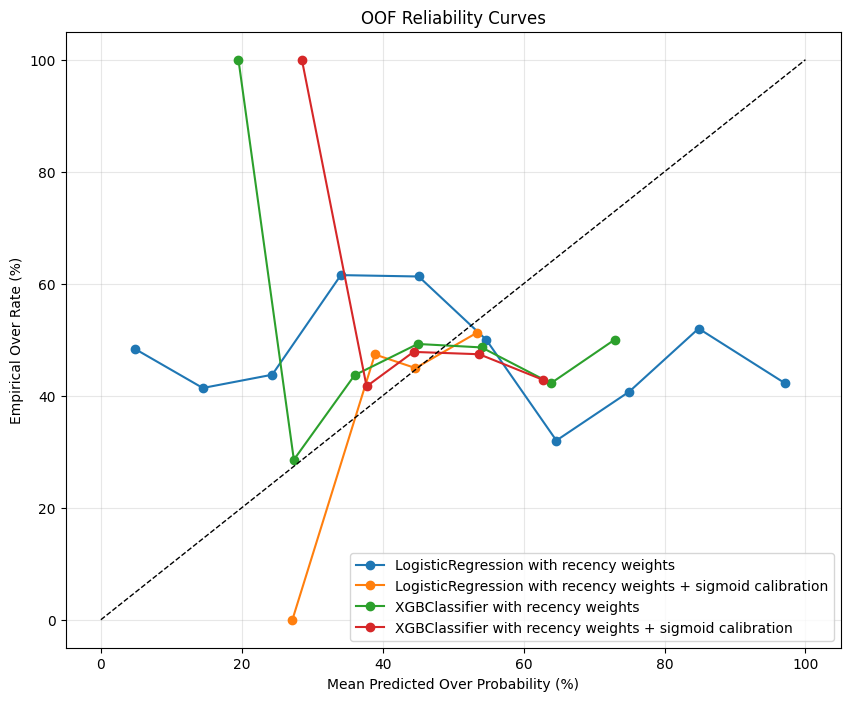

In [12]:
reliability_table_cv = build_reliability_table(classifier_cv_predictions, n_bins=10)
selected_models = [
    'LogisticRegression with recency weights',
    'LogisticRegression with recency weights + sigmoid calibration',
    'XGBClassifier with recency weights',
    'XGBClassifier with recency weights + sigmoid calibration',
]
reliability_plot_df = reliability_table_cv[
    reliability_table_cv['model'].isin(selected_models)
].copy()
reliability_plot_df = reliability_plot_df.loc[reliability_plot_df['n_games'] > 0].copy()

display(reliability_plot_df.round(3))

plt.figure(figsize=(10, 8))
for model_name, group in reliability_plot_df.groupby('model', sort=False):
    plt.plot(
        group['mean_predicted_prob'],
        group['empirical_over_rate'],
        marker='o',
        label=model_name,
    )

plt.plot([0, 100], [0, 100], linestyle='--', color='black', linewidth=1)
plt.xlabel('Mean Predicted Over Probability (%)')
plt.ylabel('Empirical Over Rate (%)')
plt.title('OOF Reliability Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [13]:
classifier_final_predictions = evaluate_final_holdout_classifiers(
    model_specs=model_specs,
    X_dev=X_dev,
    y_dev=y_dev,
    dev_dates=df_dev[DATE_COL],
    X_test_final=X_test_final,
    y_test_final=y_test_final,
    sample_weight_lambda=SAMPLE_WEIGHT_LAMBDA,
    calibration_fraction=CALIBRATION_FRACTION,
    min_calibration_games=MIN_CALIBRATION_GAMES,
    min_model_train_games=MIN_MODEL_TRAIN_GAMES,
)

classifier_final_summary = summarize_prediction_frame(classifier_final_predictions)
display(classifier_final_summary.round(4))


,model,n_games,accuracy_pct,balanced_accuracy_pct,pred_over_rate_pct,actual_over_rate_pct,brier_score,log_loss,mean_confidence_pct
0,LogisticRegression no sample weights,187,56.1497,56.2543,48.1283,52.4064,0.2807,0.8065,68.1565
1,XGBClassifier no sample weights,187,54.0107,54.7810,34.2246,52.4064,0.2488,0.6911,56.4281
2,XGBClassifier with recency weights + sigmoid c...,187,52.9412,54.5345,17.1123,52.4064,0.2521,0.6973,53.8187
3,XGBClassifier no sample weights + sigmoid cali...,187,51.8717,53.2045,22.4599,52.4064,0.2499,0.6930,55.2218
4,LogisticRegression with recency weights,187,51.3369,51.8172,40.1070,52.4064,0.3296,0.9589,74.2303
5,XGBClassifier with recency weights,187,50.2674,50.9000,36.8984,52.4064,0.2552,0.7040,56.7656
6,DummyClassifier prior + sigmoid calibration,187,47.5936,50.0000,0.0000,52.4064,0.2526,0.6983,53.2064
7,DummyClassifier prior,187,47.5936,50.0000,0.0000,52.4064,0.2504,0.6940,50.7418
8,LogisticRegression with recency weights + sigm...,187,47.0588,48.9223,11.2299,52.4064,0.2536,0.7004,53.3795
9,LogisticRegression no sample weights + sigmoid...,187,45.4545,46.8241,21.3904,52.4064,0.2551,0.7034,53.3878


In [14]:
final_threshold_summary = summarize_betting_thresholds(
    classifier_final_predictions,
    thresholds=CONFIDENCE_THRESHOLDS,
)

display(
    final_threshold_summary.sort_values(['threshold', 'bet_accuracy_pct'], ascending=[True, False]).round(3)
)


,model,threshold,n_bets,pct_of_games,bet_accuracy_pct,over_bets,under_bets
10,LogisticRegression no sample weights,0.55,155,82.888,56.774,72,83
30,XGBClassifier no sample weights,0.55,102,54.545,54.902,25,77
35,XGBClassifier no sample weights + sigmoid cali...,0.55,90,48.128,54.444,10,80
15,LogisticRegression no sample weights + sigmoid...,0.55,45,24.064,53.333,5,40
40,XGBClassifier with recency weights,0.55,97,51.872,52.577,28,69
20,LogisticRegression with recency weights,0.55,162,86.631,50.000,63,99
45,XGBClassifier with recency weights + sigmoid c...,0.55,60,32.086,48.333,4,56
25,LogisticRegression with recency weights + sigm...,0.55,41,21.925,46.341,0,41
0,DummyClassifier prior,0.55,0,0.000,NaN,0,0
5,DummyClassifier prior + sigmoid calibration,0.55,0,0.000,NaN,0,0


In [15]:
cv_common_summary = pd.concat(
    [
        baseline_cv_summary[['model', 'accuracy_pct', 'balanced_accuracy_pct']],
        classifier_cv_summary[['model', 'accuracy_pct', 'balanced_accuracy_pct', 'brier_score', 'log_loss']],
    ],
    ignore_index=True,
).sort_values('accuracy_pct', ascending=False)

final_common_summary = pd.concat(
    [
        baseline_final_summary[['model', 'accuracy_pct', 'balanced_accuracy_pct']],
        classifier_final_summary[['model', 'accuracy_pct', 'balanced_accuracy_pct', 'brier_score', 'log_loss']],
    ],
    ignore_index=True,
).sort_values('accuracy_pct', ascending=False)

print('Cross-validation comparison')
display(cv_common_summary.round(4))
print('Final holdout comparison')
display(final_common_summary.round(4))


Cross-validation comparison


,model,accuracy_pct,balanced_accuracy_pct,brier_score,log_loss
0,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,55.6757,54.0025,NaN,NaN
1,BASE_AVG_ALL_6_ERR,54.8649,53.2372,NaN,NaN
2,LogisticRegression with recency weights + sigm...,53.7838,52.7973,0.2482,0.6895
3,LogisticRegression no sample weights + sigmoid...,53.2432,52.3194,0.2482,0.6896
4,XGBClassifier no sample weights,52.7027,52.3575,0.2605,0.7157
5,XGBClassifier no sample weights + sigmoid cali...,52.1622,51.4925,0.2508,0.6949
6,DummyClassifier prior,51.8919,51.7212,0.2490,0.6911
7,XGBClassifier with recency weights + sigmoid c...,50.5405,49.9619,0.2515,0.6962
8,DummyClassifier prior + sigmoid calibration,50.2703,49.5778,0.2486,0.6904
9,XGBClassifier with recency weights,50.2703,49.8358,0.2610,0.7166


Final holdout comparison


,model,accuracy_pct,balanced_accuracy_pct,brier_score,log_loss
2,LogisticRegression no sample weights,56.1497,56.2543,0.2807,0.8065
3,XGBClassifier no sample weights,54.0107,54.7810,0.2488,0.6911
4,XGBClassifier with recency weights + sigmoid c...,52.9412,54.5345,0.2521,0.6973
0,BASE_MAJORITY_ALL_6_TIE_WITH_PRED_LINE_ERROR_F...,52.4064,52.7861,NaN,NaN
5,XGBClassifier no sample weights + sigmoid cali...,51.8717,53.2045,0.2499,0.6930
6,LogisticRegression with recency weights,51.3369,51.8172,0.3296,0.9589
1,BASE_AVG_ALL_6_ERR,50.2674,50.8484,NaN,NaN
7,XGBClassifier with recency weights,50.2674,50.9000,0.2552,0.7040
8,DummyClassifier prior + sigmoid calibration,47.5936,50.0000,0.2526,0.6983
9,DummyClassifier prior,47.5936,50.0000,0.2504,0.6940
